# Demonstrate how to convert healpix to lat/lon and then to iris cube

* Computes number of latitude and longitude points equating to input zoom (or define an analysis grid)
* Uses nearest neighbour interpolation.
* Plots the results using iris plotting.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr
import iris
import iris.plot as iplt
import iris.quickplot as qplt

In [2]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [20]:
# Define function to compute number of latitude and longitude points appropriate for each Healpix zoom
# For more approximate computation, nlon ~ 4*nside; nlat ~ 3*nside
def healpix_zoom_to_grid_area_match(zoom):
    nside = 2.0**zoom

    # Healpix pixel area
    pixel_area = 4 * np.pi / (12 * nside**2)

    # Angular resolution
    theta = np.sqrt(pixel_area)

    # Compute nlon, nlat
    nlon = int(round(2 * np.pi / theta))
    nlat = int(round(np.pi / theta))

    return nlon, nlat

In [4]:
# Define function to translate from healpix to lat lon [could sit in utils.py, but showing here for transparency]
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        hp.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("latitude", lats), ("longitude", lons)],
    )

In [5]:
# Define a function to generate iris cube from xarray Dataset
def xarray_to_iris(dataset, varname):
    
    # Convert from xarray to iris cube
    cube = dataset[varname].to_iris()

    # Add more metadata to lat and lon coords
    for cube_coord in ["latitude", "longitude"]:
        cube.coord(cube_coord).units="degrees"
        cube.coord(cube_coord).coord_system=iris.coord_systems.GeogCS(6371229.0)
        cube.coord(cube_coord).guess_bounds()
        
    # Remove crs coord
    cube.remove_coord("crs")
    
    # Rename index coord
    cube.coord("healpix_index").rename("cell")

    # Set standard_calendar for time coord
    cube.coord("time").units = cube.coord("time").units.change_calendar("standard")

    return cube

In [6]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

In [7]:
# Print all catalog entries
print([k for k in cat])

['CERES_EBAF', 'ERA5', 'IR_IMERG', 'JRA3Q', 'MERRA2', 'arp-gem-1p3km', 'arp-gem-2p6km', 'casesm2_10km_nocumulus', 'icon_d3hp003', 'icon_d3hp003aug', 'icon_d3hp003feb', 'icon_ngc4008', 'ifs_tco3999-ng5_deepoff', 'ifs_tco3999-ng5_rcbmf', 'ifs_tco3999-ng5_rcbmf_cf', 'ifs_tco3999_rcbmf', 'nicam_220m_test', 'nicam_gl11', 'scream-dkrz', 'tracking-d3hp003', 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest', 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_glm_n1280_CoMA9_TBv1p2', 'um_glm_n1280_CoMA9_hk26', 'um_glm_n1280_GAL9', 'um_glm_n12

In [8]:
# Print all hk26 catalog entries
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [9]:
# Load specific model
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat = cat()[sim]

In [10]:
# Open a 1h (2D) and 3h (3D) dataset - work with lo-res and hi-res example healpix
zoom_lr = 2
ds1h_lr = sim_cat(zoom=zoom_lr, time='PT1H').to_dask()
ds3h_lr = sim_cat(zoom=zoom_lr, time='PT3H').to_dask()

In [11]:
# Open a 1h (2D) and 3h (3D) dataset - work with lo-res and hi-res example healpix
zoom_hr = 8
ds1h_hr = sim_cat(zoom=zoom_hr, time='PT1H').to_dask()
ds3h_hr = sim_cat(zoom=zoom_hr, time='PT3H').to_dask()

In [12]:
ds1h_lr

<xarray.Dataset> Size: 225MB
Dimensions:        (time: 9745, healpix_index: 192, depth: 4)
Coordinates:
  * time           (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * healpix_index  (healpix_index) int64 2kB 0 1 2 3 4 5 ... 187 188 189 190 191
  * depth          (depth) float32 16B 0.05 0.225 0.675 2.0
    crs            int32 4B ...
Data variables: (12/29)
    clivi          (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    clt            (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    clwvi          (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    hflso          (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    hfsso          (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    huss           (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    ...             ...
    rsutcs         (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    sftlf          (healpix_index) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
    tas            (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    ts             (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    uas            (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
    vas            (time, healpix_index) float32 7MB dask.array<chunksize=(4096, 192), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

In [13]:
ds3h_hr

<xarray.Dataset> Size: 3TB
Dimensions:        (time: 3249, pressure: 25, healpix_index: 786432)
Coordinates:
  * time           (time) datetime64[ns] 26kB 2020-01-20 ... 2021-03-01
  * pressure       (pressure) int64 200B 1 5 10 20 30 ... 900 925 950 975 1000
  * healpix_index  (healpix_index) int64 6MB 0 1 2 3 ... 786429 786430 786431
    crs            int32 4B ...
Data variables: (12/14)
    cli            (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    clw            (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    hur            (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    hus            (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    orog           (healpix_index) float64 6MB dask.array<chunksize=(49152,), meta=np.ndarray>
    qg             (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    ...             ...
    sftlf          (healpix_index) float64 6MB dask.array<chunksize=(49152,), meta=np.ndarray>
    ta             (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    ua             (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    va             (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    wa             (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
    zg             (time, pressure, healpix_index) float32 256GB dask.array<chunksize=(16, 5, 65536), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

In [15]:
# OPTION 1: Define an analyisis grid (e.g. 1 degree global) - used to output all zoom levels to same analysis grid.
#           Caution uses nearest neighbour interpolation. May be useful for exploring data and testing ideas, or 
#           where matching to e.g. observations grid.
lon1 = 0
lon2 = 360
nlon = 360
lons = np.linspace(lon1, lon2, nlon)

lat1 = -90
lat2 = 90
nlat = 180
lats = np.linspace(lat1, lat2, nlat)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons, lats)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons, lats)

In [51]:
# OPTION2: (Recommended) Compute number of lat and lon points equivalent to Healpix zoom level
#          Note option to define lons [0,360] or [-180,180]

# Call function to compute nlon, nlat based on zoom level
nlon_lr, nlat_lr = healpix_zoom_to_grid_area_match(zoom_lr)
lons_lr = np.linspace(0, 360, nlon_lr)
lats_lr = np.linspace(-90, 90, nlat_lr)

nlon_hr, nlat_hr = healpix_zoom_to_grid_area_match(zoom_hr)
lons_hr = np.linspace(0, 360, nlon_hr)
lats_hr = np.linspace(-90, 90, nlat_hr)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons_lr, lats_lr)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons_hr, lats_hr)

In [50]:
# Reorganise 1hr xarray 1d Dataset to 2d Dataset with lat/lon dimensions
ds1h_lr_latlon = ds1h_lr.isel(healpix_index=idx_lr)
ds1h_hr_latlon = ds1h_hr.isel(healpix_index=idx_hr)

ds3h_lr_latlon = ds3h_lr.isel(healpix_index=idx_lr)
ds3h_hr_latlon = ds3h_hr.isel(healpix_index=idx_hr)

In [37]:
ds3h_lr_latlon

<xarray.Dataset> Size: 1GB
Dimensions:        (time: 3249, pressure: 25, latitude: 12, longitude: 25)
Coordinates:
  * time           (time) datetime64[ns] 26kB 2020-01-20 ... 2021-03-01
  * pressure       (pressure) int64 200B 1 5 10 20 30 ... 900 925 950 975 1000
  * latitude       (latitude) float64 96B -90.0 -73.64 -57.27 ... 73.64 90.0
  * longitude      (longitude) float64 200B -180.0 -165.0 -150.0 ... 165.0 180.0
    healpix_index  (latitude, longitude) int64 2kB 160 160 160 160 ... 31 31 47
    crs            int32 4B ...
Data variables: (12/14)
    cli            (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    clw            (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    hur            (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    hus            (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    orog           (latitude, longitude) float64 2kB dask.array<chunksize=(7, 25), meta=np.ndarray>
    qg             (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    ...             ...
    sftlf          (latitude, longitude) float64 2kB dask.array<chunksize=(7, 25), meta=np.ndarray>
    ta             (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    ua             (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    va             (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    wa             (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
    zg             (time, pressure, latitude, longitude) float32 97MB dask.array<chunksize=(3249, 5, 7, 25), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

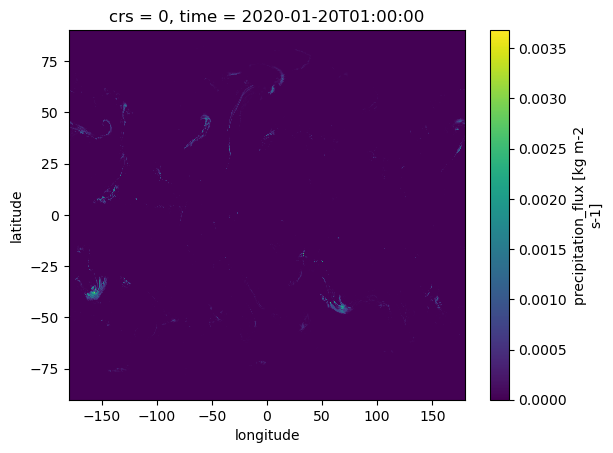

In [38]:
# Check sample regridded xarray variable output (hi-res)
ds1h_hr_latlon.isel(time=1).pr.plot()

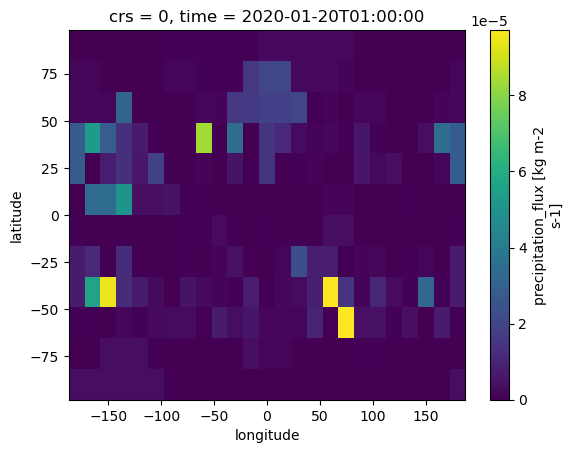

In [39]:
# Check sample regridded xarray variable output (lo-res)
ds1h_lr_latlon.isel(time=1).pr.plot()

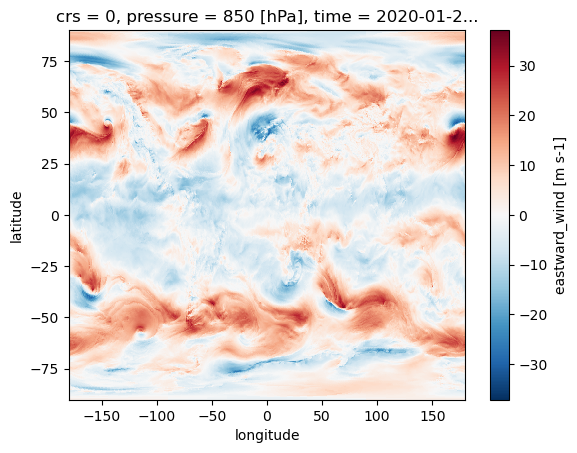

In [40]:
# Check sample regridded 3hr xarray variable output (hi-res)
ds3h_hr_latlon.isel(time=1).sel(pressure=850).ua.plot()

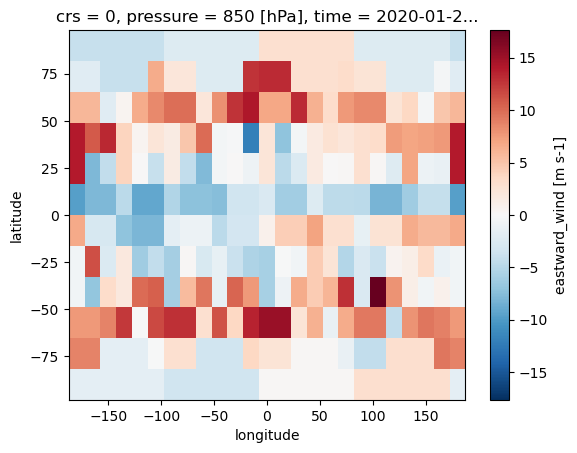

In [41]:
# Check sample regridded 3hr xarray variable output (lo-res)
ds3h_lr_latlon.isel(time=1).sel(pressure=850).ua.plot()

In [42]:
# Convert from xarray to iris cube
temp_hr_cube = xarray_to_iris(ds1h_hr_latlon, "tas")
temp_lr_cube = xarray_to_iris(ds1h_lr_latlon, "tas")

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [43]:
temp_hr_cube

<iris 'Cube' of air_temperature / (K) (time: 9745; latitude: 786; longitude: 1572)>

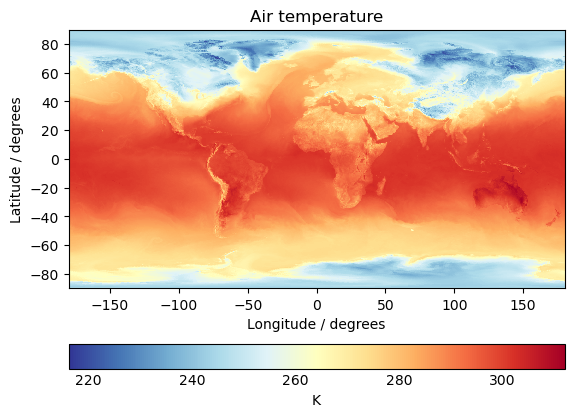

In [44]:
# Use iris quickplot for quick-look plot
qplt.pcolormesh(temp_hr_cube[1],cmap='RdYlBu_r')

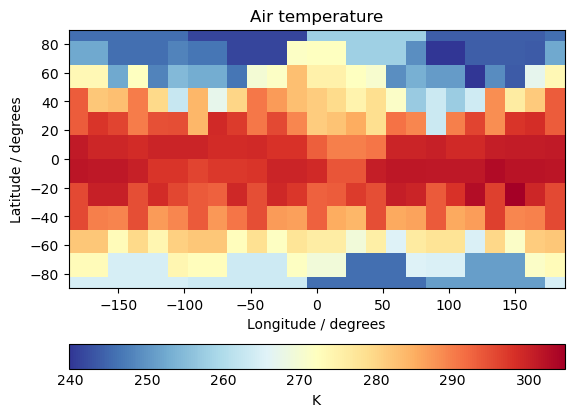

In [45]:
# Use iris quickplot for quick-look plot
qplt.pcolormesh(temp_lr_cube[1],cmap='RdYlBu_r')

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/cube.py:4665: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/coords.py:2302: IrisVagueMetadataWarning: Collapsing a multi-dimensional coordinate. Metadata may not be fully descriptive for 'cell'.
  warnings.warn(
/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


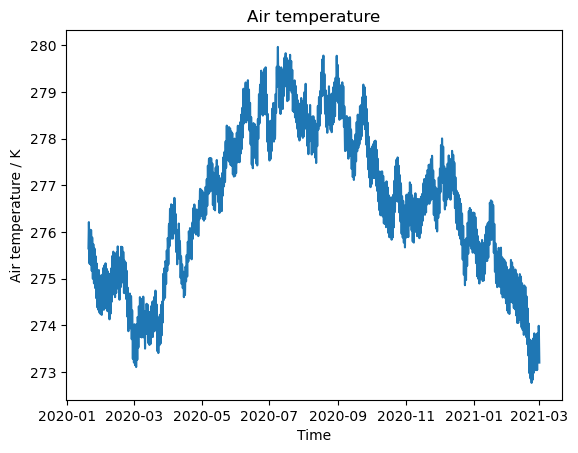

In [46]:
# Use iris analysis to compute global average timeseries (only compute for lo-res input given global mean output)
t_mean = temp_lr_cube.collapsed(["latitude","longitude"], iris.analysis.MEAN)
qplt.plot(t_mean)

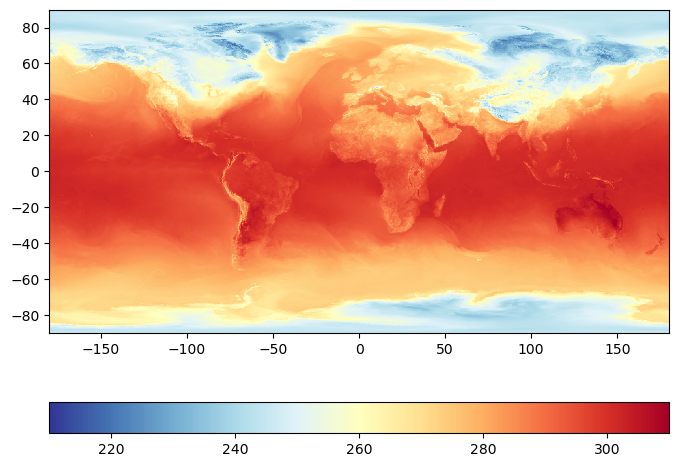

In [47]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_hr_cube[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

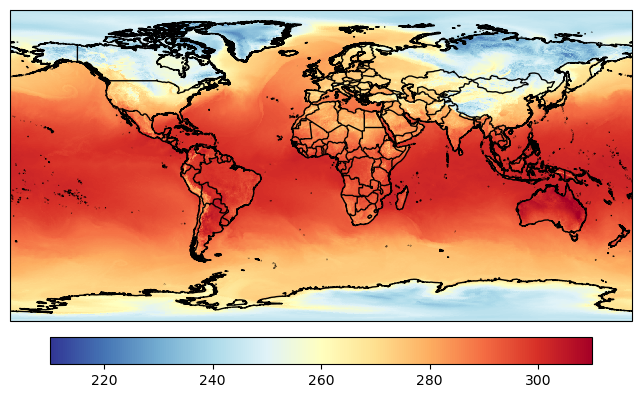

In [48]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_hr_cube[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)